In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d0f6e60819f9a5a.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccf708985967f09.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9ccbc2c5d1aaf078.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bdcc23296db1516.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9cb97f87870407f0.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9bf9cca507923334.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9c077ad23a231abb.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d6a6499354e3197.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9c3f1c10ba54ed56.jpg
/kaggle/input/plant-disease-recognition-dataset/Validation/Validation/Healthy/9d6acb154f9932c8.jpg
/kaggle/in

In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset paths
train_dir = '/kaggle/input/plant-disease-recognition-dataset/Train/Train'
val_dir = '/kaggle/input/plant-disease-recognition-dataset/Validation/Validation'

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [10]:
import json

with open("class_mapping.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f)

print("Saved class mapping:", train_dataset.class_to_idx)

Saved class mapping: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}


In [11]:
from torchvision.models import densenet121, DenseNet121_Weights
import torch.nn as nn

# Load pretrained DenseNet121
weights = DenseNet121_Weights.DEFAULT
model = densenet121(weights=weights)

# Freeze feature extractor (optional)
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier layer to match your number of classes
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(train_dataset.classes))
)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [12]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

num_epochs = 15  # You can increase this as needed
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    torch.cuda.empty_cache()

# Save training metrics
torch.save({
    'train_acc': train_accuracies,
    'val_acc': val_accuracies,
    'train_loss': train_losses,
    'val_loss': val_losses
}, 'training_metrics.pth')

Epoch 1/15
Train Loss: 0.5477, Train Acc: 0.7958 | Val Loss: 0.2407, Val Acc: 0.9667


Epoch 2/15
Train Loss: 0.2422, Train Acc: 0.9085 | Val Loss: 0.1406, Val Acc: 0.9667


Epoch 3/15
Train Loss: 0.1707, Train Acc: 0.9470 | Val Loss: 0.1100, Val Acc: 0.9500


Epoch 4/15
Train Loss: 0.1815, Train Acc: 0.9402 | Val Loss: 0.1000, Val Acc: 0.9667


Epoch 5/15
Train Loss: 0.1455, Train Acc: 0.9501 | Val Loss: 0.1251, Val Acc: 0.9833


...

Epoch 11/15
Train Loss: 0.1397, Train Acc: 0.9478 | Val Loss: 0.0824, Val Acc: 0.9667


Epoch 12/15
Train Loss: 0.1945, Train Acc: 0.9365 | Val Loss: 0.0812, Val Acc: 0.9833


Epoch 13/15
Train Loss: 0.1116, Train Acc: 0.9569 | Val Loss: 0.0708, Val Acc: 0.9833


Epoch 14/15
Train Loss: 0.0926, Train Acc: 0.9660 | Val Loss: 0.0912, Val Acc: 0.9833


Epoch 15/15
Train Loss: 0.0823, Train Acc: 0.9667 | Val Loss: 0.0568, Val Acc: 0.9667


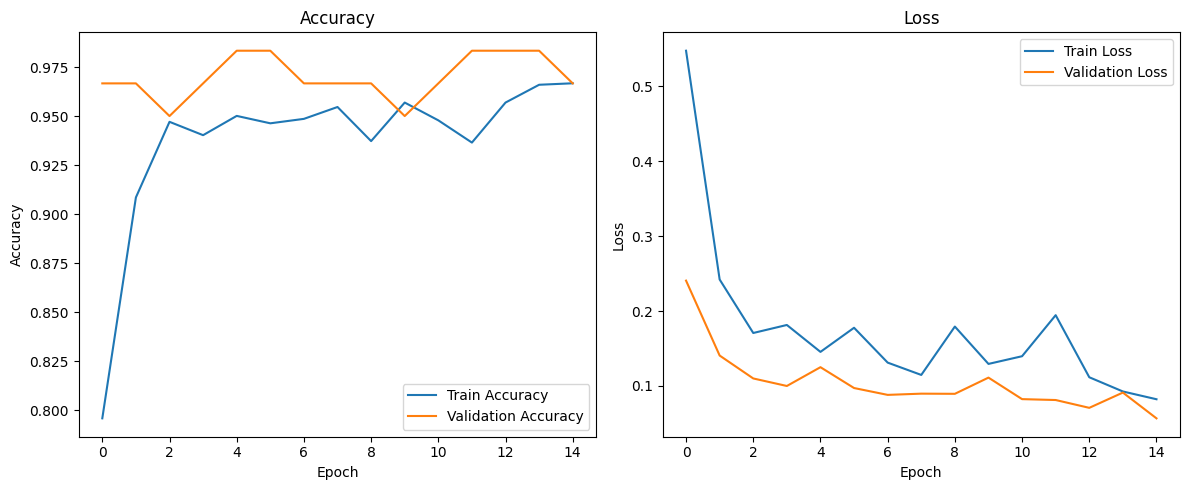

In [13]:
import matplotlib.pyplot as plt

torch.save({
    'train_acc': train_accuracies,
    'val_acc': val_accuracies,
    'train_loss': train_losses,
    'val_loss': val_losses
}, 'training_metrics.pth')

metrics = torch.load("training_metrics.pth")

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(metrics['train_acc'], label='Train Accuracy')
plt.plot(metrics['val_acc'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(metrics['train_loss'], label='Train Loss')
plt.plot(metrics['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

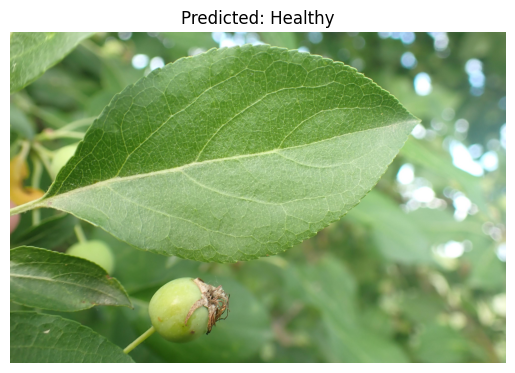

In [14]:
from torchvision.models import densenet121
from PIL import Image

# Load class mapping
with open("class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

# Reverse mapping
class_names = [None] * len(class_to_idx)
for name, idx in class_to_idx.items():
    class_names[idx] = name

# Load DenseNet121 model structure
model = densenet121(weights=None)
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, len(class_names))
)

# Load trained weights
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

# Load and preprocess image
img_path = "/kaggle/input/plant-disease-recognition-dataset/Test/Test/Healthy/8ddd5ec1c0de38c4.jpg"
image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

# Make prediction
with torch.no_grad():
    output = model(input_tensor)
    predicted_idx = torch.argmax(output, 1).item()
    predicted_class = class_names[predicted_idx]

# Display result
plt.imshow(image)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()
